# **Getting Requirements**

This uses Python 3.10.x 

In [118]:
! pip install matplotlib pandas mplfinance marketprofile plotly yfinance-cache
! pip install yfinance --upgrade --no-cache-dir
! pip install --upgrade nbformat
! pip install IPython IPython notebook


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aider-chat 0.13.0 requires jsonschema==4.17.3, but you have jsonschema 4.21.1 which is incompatible.
aider-chat 0.13.0 requires prompt-toolkit==3.0.38, but you have prompt-toolkit 3.0.43 which is incompatible.
aider-chat 0.13.0 requires requests==2.30.0, but you have requests 2.31.0 which is incompatible.
aider-chat 0.13.0 requires urllib3==2.0.2, but you have urllib3 1.26.16 which is incompatible.
aiogram 2.25.1 requires Babel<2.10.0,>=2.9.1, but you have babel 2.14.0 which is incompatible.
python-telegram-bot 20.4 requires httpx~=0.24.1, but you have httpx 0.27.0 which is incompatible.



   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/5.0 MB 1.7 MB/s eta 0:00:03
   - -------------------------------------- 0.1/5.0 MB 1.7 MB/s eta 0:00:03
   - -------------------------------------- 0.2/5.0 MB 1.7 MB/s eta 0:00:03
   -- ------------------------------------- 0.3/5.0 MB 1.7 MB/s eta 0:00:03
   --- ------------------------------------ 0.4/5.0 MB 1.8 MB/s eta 0:00:03
   --- ------------------------------------ 0.5/5.0 MB 1.8 MB/s eta 0:00:03
   ---- ----------------------------------- 0.6/5.0 MB 1.9 MB/s eta 0:00:03
   ----- ---------------------------------- 0.7/5.0 MB 1.9 MB/s eta 0:00:03
   ------ --------------------------------- 0.8/5.0 MB 1.9 MB/s eta 0:00:03
   ------- -------------------------------- 0.9/5.0 MB 1.9 MB/s eta 0:00:03
   ------- -------------------------------- 1.0/5.0 MB 2.0 MB/s eta 0:00:03
   -------- ------------------------------- 1.1/5.0 MB 2.0 MB/s eta 0:00:02
   ---------- ----

# **Imports**

In [119]:
# Standard library imports
from datetime import datetime, timedelta
import concurrent.futures

# Third-party imports
import matplotlib.pyplot as plt
import mplfinance as mpf
import numpy as np
import time
from tqdm import tqdm
import nbformat
print(nbformat.__version__)
import random
import pandas as pd
import pandas_datareader as pdr
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Markdown
from IPython.display import display
from IPython.display import HTML
import plotly.graph_objects as go

import yfinance as yf
# import yfinance_cache as yfc

# Local application/library specific imports
from market_profile import MarketProfile

5.10.3


# **Get all Companies from CSV and Fetch Initial Data**

In [80]:
file_path = './tickers.csv'  # Updated to a relative path for broader applicability

try:
    # Try loading the file. Adjust encoding if needed.
    data = pd.read_csv(file_path, encoding='ISO-8859-1')

    # Define the set of expected columns for validation.
    expected_columns = {'ticker'}

    # Check if the expected columns are present in the loaded data.
    if set(data.columns) & expected_columns == expected_columns:
        print('CSV file loaded successfully with the expected headers.')
        companies = data['ticker'].tolist()
    else:
        missing_columns = expected_columns - set(data.columns)
        print(f'CSV file is missing the following required columns: {missing_columns}')
        companies = []
except Exception as e:
    print(f'An error occurred while loading the CSV file: {e}')
    companies = []

print("Total number of initial companies is: " + len(companies))

# Adjust or confirm the cache folder path as per your environment.
cache_folder = './colab_cache/'  # Adjusted to a more generic path unless you are specifically working within Google Colab.

def populate_metrics(ticker, metrics):
    if ticker and hasattr(ticker, 'info'):
        stock_info = ticker.info
        metrics['eps_values'].append(stock_info.get('trailingEps', 0))
        metrics['pe_values'].append(stock_info.get('trailingPE', 0))
        metrics['peg_values'].append(stock_info.get('pegRatio', 0))
        metrics['gross_margins'].append(stock_info.get('grossMargins', 0))
        metrics['company_labels'].append(ticker.ticker)
    else:
        print(f"Skipped a company ticker due to missing info or an invalid object.")

def worker(company, metrics):
    try:
        ticker = yf.Ticker(company)
        populate_metrics(ticker, metrics)
    except Exception as e:
        print(f"Failed to fetch data for {company}. Error: {e}")

def fetch_metrics_data(companies):
    metrics = {metric: [] for metric in ['eps_values', 'pe_values', 'peg_values', 'gross_margins', 'company_labels']}

    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        futures = [executor.submit(worker, company, metrics) for company in companies]
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(companies), desc="Fetching metrics"):
            # This loop is primarily to keep tqdm updated, handling of results (if any) would go here
            pass

    return metrics

# Example of usage
metrics = fetch_metrics_data(companies)


CSV file loaded successfully with the expected headers.
1122


# **Parametters**

In [140]:
# Time period settings
days_history = 365 * 5  # looking 5 years back
interval_dates = '3mo'  # each candle represents a quarter

# Company performance indicators
eps_threshold = 5  # interested in high revenue companies
gross_margin_threshold = 20  # minimum acceptable gross margin
ps_threshold = 1  # minimum acceptable gross margin

# Valuation metrics
peg_threshold_low = -0.2  # anything under 0 is overvalued or is not cash generating
peg_threshold_high = 1.2  # anything over 1 is overvalued

def get_date_range(days_back):
    """Helper function to compute start and end date strings."""
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    return start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')

start_date_str, end_date_str = get_date_range(days_history)

# **Filtering Methods**

In [136]:
def filter_companies(metrics, eps_threshold, peg_threshold_low, peg_threshold_high, gross_margin_threshold):
    try:
        # Create DataFrame from metrics
        df = pd.DataFrame({
            'company': metrics['company_labels'],
            'eps': metrics['eps_values'],
            'pe': metrics['pe_values'],
            # 'ps': metrics['ps_values'],
            # 'pb': metrics['pb_values'],
            'peg': metrics['peg_values'],
            'gross_margin': metrics['gross_margins']
        })

        # Normalize gross margin if max is less than or equal to 1 (assuming it's in decimals rather than percentage)
        if df['gross_margin'].max() <= 1:
            df['gross_margin'] *= 100

        # Criteria for filtering - each condition needs to be enclosed in parentheses
        criteria = (df['eps'] > eps_threshold) & \
                   (df['gross_margin'] > gross_margin_threshold) & \
                   (df['peg'] > peg_threshold_low) & (df['peg'] <= peg_threshold_high)

        # Apply criteria to filter DataFrame
        filtered_df = df[criteria]

        # Sort filtered DataFrame by 'pe' in ascending order
        filtered_df_sorted = filtered_df.sort_values(by='pe', ascending=True)

        # Print the filtered DataFrame
        print(f"Filtered down to {len(filtered_df_sorted)} companies based on criteria.")

        return filtered_df_sorted
    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame()

def classify_by_industry(tickers):
    industries = {}
    for ticker in tickers.tickers.values():
        sector = ticker.info.get('sector')
        if sector:
            industries.setdefault(sector, []).append(ticker.ticker)
    return industries

def fetch_industries(companies):
    tickers = yf.Tickers(' '.join(companies))
    industries = classify_by_industry(tickers)
    return industries

def fetch_recommendations_summary(ticker):
    """Fetch a structured summary of recommendations for a given ticker."""
    try:
        rec_data = ticker.get_recommendations_summary()
        if not rec_data.empty:
            return {row['period']: {
                'strongBuy': row['strongBuy'],
                'buy': row['buy'],
                'hold': row['hold'],
                'sell': row['sell'],
                'strongSell': row['strongSell']
            } for index, row in rec_data.iterrows()}
        else:
            return "No recommendation data available."
    except Exception as e:
        return f"Error: {str(e)}"

def fetch_company_news(ticker):
    """Fetches the latest news related to a given ticker."""
    try:
        news_articles = ticker.news
        organized_news = []
        for article in news_articles:
            organized_article = {
                'title': article['title'],
                'publisher': article['publisher'],
                'link': article['link'],
                'published_date': article['providerPublishTime']
            }
            organized_news.append(organized_article)
        return organized_news
    except Exception as e:
        return f"Error fetching news: {str(e)}"

def populate_additional_metrics(ticker, metrics):
    """Populates a given metrics dictionary with data fetched from a ticker object."""
    stock_info = ticker.info
    metrics['recommendations_summary'].append(fetch_recommendations_summary(ticker))

    if 'news' not in metrics:
        metrics['news'] = []
    # Assuming fetch_company_news(ticker) returns a list of news items
    metrics['news'] += fetch_company_news(ticker)  # Use += to extend the list instead of replacing it

    metrics['ps_values'].append(stock_info.get('priceToSalesTrailing12Months', 0))
    metrics['pb_values'].append(stock_info.get('priceToBook', 0))
    metrics['market_caps'].append(stock_info.get('marketCap', 0))

def augment_metrics_with_live_data(companies, original_metrics):
    augmented_data = {metric: [] for metric in original_metrics}  # Prepare structure
    augmented_data.update({  # Prepare for additional data
        'recommendations_summary': [],
        'news': [],
        'ps_values': [],
        'pb_values': [],
        'market_caps': []
    })

    for company_symbol in companies:
        try:
            # Assuming you have a way to get a ticker object for the company symbol
            ticker = get_ticker_object(company_symbol)  # You'll need to define this based on your data source/API

            # Initialize an empty dict for individual company metrics
            company_metrics = {metric: [] for metric in augmented_data}

            # Use populate_additional_metrics to fill company_metrics with live data
            populate_additional_metrics(ticker, company_metrics)

            # Now, append or extend each key in company_metrics to augmented_data
            for key, value in company_metrics.items():
                if isinstance(value, list) and key in augmented_data:  # Handling list types specifically
                    augmented_data[key].extend(value)
                else:
                    augmented_data[key].append(value)
        except Exception as e:
            print(f"Error processing company {company_symbol}: {e}")
            # Handle missing data or errors as needed, possibly skipping or using placeholder data

    return augmented_data

def get_ticker_object(symbol):
    """
    Given a symbol, returns a Ticker object using the yfinance library.
    :param symbol: The stock symbol (e.g., 'AAPL' for Apple Inc.)
    :return: yfinance.Ticker object containing information about the symbol
    """
    ticker = yf.Ticker(symbol)
    return ticker

def fetch_additional_metrics_data(companies):
    """Fetches and structures various financial metrics for the given list of company tickers."""
    tickers = yf.Tickers(' '.join(companies))
    metrics = {metric: [] for metric in ['ps_values', 'pb_values',
                                     'market_caps', 'recommendations_summary', 'news']}
    metrics['price_diff'] = {}

    for company in companies:
        try:
            ticker = tickers.tickers[company]
            populate_additional_metrics(ticker, metrics)
        except KeyError:
            print(f"Warning: Ticker {company} not found. Skipping.")

    return metrics

def build_combined_metrics(filtered_company_symbols, metrics, metrics_filtered):
    # Remove 'companies_fetched' if present in both dictionaries
    metrics.pop('companies_fetched', None)
    metrics_filtered.pop('companies_fetched', None)

    # Initialize combined_metrics excluding 'company_labels' explicitly as it's handled separately
    combined_metrics = {key: [] for key in set(list(metrics.keys()) + list(metrics_filtered.keys())) - {'company_labels', 'companies_fetched'}}

    # Directly use 'filtered_company_symbols' as the authoritative list of companies
    combined_metrics['company_labels'] = filtered_company_symbols

    for symbol in filtered_company_symbols:
        # Derive index from 'company_labels' in 'metrics' if it exists
        metrics_index = metrics['company_labels'].index(symbol) if 'company_labels' in metrics and symbol in metrics['company_labels'] else -1

        for key in combined_metrics:
            if key == 'company_labels':  # Skip 'company_labels' here since it's already handled
                continue

            # Process metrics from the 'metrics' dictionary
            if key in metrics and metrics_index >= 0:
                if isinstance(metrics[key], list) and len(metrics[key]) > metrics_index:
                    combined_metrics[key].append(metrics[key][metrics_index])
                else:
                    combined_metrics[key].append(None)  # Handle missing or misaligned data

            # Process additional metrics from the 'metrics_filtered' dictionary
            elif key in metrics_filtered:
                # We assume 'metrics_filtered' directly mirrors 'filtered_company_symbols' in sequence
                filtered_index = filtered_company_symbols.index(symbol)
                if isinstance(metrics_filtered[key], list) and len(metrics_filtered[key]) > filtered_index:
                    combined_metrics[key].append(metrics_filtered[key][filtered_index])
                else:
                    combined_metrics[key].append(None)  # Handle missing or misaligned data
            else:
                # If the key doesn't exist in 'metrics' when processing, initialize missing entries with None
                if key not in metrics:
                    combined_metrics[key].append(None)

    return combined_metrics

filtered_companies_df = filter_companies(metrics, eps_threshold, peg_threshold_low, peg_threshold_high, gross_margin_threshold)

filtered_company_symbols = filtered_companies_df['company'].tolist()

metrics_filtered = fetch_additional_metrics_data(filtered_company_symbols)

combined_metrics = build_combined_metrics(filtered_company_symbols, metrics, metrics_filtered)

filtered_industries = fetch_industries(filtered_company_symbols)
industries = fetch_industries(companies)

Filtered down to 37 companies based on criteria.


In [141]:
def fetch_historical_data(ticker, start_date, end_date, period=None, interval=interval_dates):
    try:
        if period:
            data = ticker.history(period=period, interval=interval)
        else:
            data = ticker.history(start=start_date, end=end_date, interval=interval)
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame()  # Return an empty DataFrame

def calculate_price_diff(companies):
    tickers = yf.Tickers(' '.join(companies))
    price_diff = {}  # Store price difference info here

    for company in companies:
        ticker = tickers.tickers[company]
        hist = fetch_historical_data(ticker, None, None, period="1y")
        if not hist.empty:
            today_price = hist['Close'].iloc[-1]
            high_52week = max(hist['High'])
            low_52week = min(hist['Low'])
            high_percent_diff = ((today_price - high_52week) / high_52week) * 100
            low_percent_diff = ((today_price - low_52week) / low_52week) * 100
            price_diff[company] = {'high_diff': -1 * high_percent_diff, 'low_diff': low_percent_diff}

    return price_diff

def fetch_price_diff(companies, combined_metrics):
    price_diff = calculate_price_diff(companies)
    combined_metrics['price_diff'] = price_diff

    return combined_metrics

combined_metrics = fetch_price_diff(filtered_company_symbols, combined_metrics)

def plot_combined_interactive(combined_metrics):
    # Extract data for all plots
    company_labels = combined_metrics['company_labels']
    eps_values = combined_metrics['eps_values']
    high_diffs = [combined_metrics['price_diff'][company]['high_diff'] for company in company_labels]
    low_diffs = [combined_metrics['price_diff'][company]['low_diff'] for company in company_labels]
    market_caps = combined_metrics['market_caps']
    pb_values = combined_metrics['pb_values']
    pe_values = combined_metrics['pe_values']
    peg_values = combined_metrics['peg_values']
    ps_values = combined_metrics['ps_values']
    gross_margins = combined_metrics['gross_margins']
    recommendations_summary = combined_metrics['recommendations_summary']

    # Normalize PEG sizes for Plot 4 visualization
    peg_min = min(peg_values)
    peg_max = max(peg_values)
    norm_peg_sizes = [(peg - peg_min) / (peg_max - peg_min) * 30 + 10 for peg in peg_values]

    # Adjust the subplot layout
    fig = make_subplots(rows=3, cols=3,  # Update to 3 rows
                        subplot_titles=("Price Difference % Over the Last Year",
                                        "EPS vs P/E Ratio",
                                        "Gross Margin (%)",
                                        "EPS vs P/B Ratio",
                                        "EPS vs PEG Ratio",
                                        "EPS vs P/S Ratio",
                                        "Upgrades & Downgrades Timeline"),  # Adjusted to be in the third row now
                        specs=[
                            [{}, {}, {}],  # First row: 3 individual cells for plots
                            [{}, {}, {}],  # New second row: 3 individual cells for new plots
                            [{"colspan": 3, "type": "scatter"}, None, None]  # Third row: A plot spanning all 3 columns
                        ],
                        vertical_spacing=0.1  # Adjust spacing if needed for aesthetics
                        )

    colors = {company: f'hsl({(i / len(company_labels) * 360)},100%,50%)' for i, company in enumerate(company_labels)}

    ## sorting the gross margin bar charts
    sorted_data = sorted(zip(company_labels, gross_margins, colors), key=lambda x: x[1], reverse=True)  # Sort by gross_margin in descending order
    sorted_labels, sorted_gross_margins, sorted_colors = zip(*sorted_data)

    for i, company in enumerate(company_labels):
        legendgroup = f"group_{company}"
        marker_size = max(market_caps[i] / max(market_caps) * 50, 5)

        # Plot 1: Price Difference
        fig.add_trace(
            go.Scatter(
                x=[high_diffs[i]],
                y=[low_diffs[i]],
                marker=dict(size=10, color=colors[company]),
                legendgroup=legendgroup,
                name=company,
                hoverinfo='none',  # Disables default hover info, to use hovertemplate completely.
                hovertemplate=f'Company: {company}<br>High Diff: %{{x}}<br>Low Diff: %{{y}}<extra></extra>',  # Custom hover
            ),
            row=1, col=1
        )

        # Plot 2: EPS vs P/E Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[pe_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/E Ratio: {pe_values[i]}<extra></extra>',  # Custom hover
            ),
            row=1, col=2
        )

        # Plot 3: Gross Margin Bar Chart
        fig.add_trace(go.Bar(
            x=[company_labels[i]],
            y=[gross_margins[i] * 100],
            marker=dict(color=colors[company]),
            legendgroup=legendgroup,
            showlegend=False,
            width=0.8  # Adjust this value as needed
        ), row=1, col=3)

        # Plot 4:  EPS vs P/B Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[pb_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/B Ratio: {pb_values[i]}<extra></extra>',  # Custom hover
            ),
            row=2, col=1
        )

        # Plot 5:  EPS vs PEG Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[peg_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>PEG Ratio: {peg_values[i]}<extra></extra>',
            ),
            row=2, col=2
        )

        # Plot 6:  EPS vs P/S Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[ps_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/S Ratio: {ps_values[i]}<extra></extra>',  # Custom hover
            ),
            row=2, col=3
        )

        # Plot 7: Recommendations Summary
        current_recommendations = recommendations_summary[i]

        if isinstance(current_recommendations, dict) and '0m' in current_recommendations:
            ratings = current_recommendations['0m']
            rating_categories = ['strongBuy', 'buy', 'hold', 'sell', 'strongSell']
            rating_values = [ratings.get(category, 0) for category in rating_categories]

            # Preparing data for bar plot
            y_categories = list(rating_categories) # Convert category names to numeric values
            category_names = {index: name for index, name in enumerate(rating_categories)} # Map for axis ticks

            # Use the count as bar height
            bar_heights = rating_values

            # Add bar chart to the subplot
            fig.add_trace(
                go.Bar(
                    x=rating_categories,  # Categories on the x-axis
                    y=bar_heights,  # Corresponding values on the y-axis
                    marker=dict(color=colors[company]),
                    name=company,
                    legendgroup=legendgroup,
                    showlegend=False,
                    text=company,  # Display company names
                    hoverinfo='y+text'  # Show hover text and value
                ),
                row=3, col=1
            )

            fig.update_yaxes(range=[0, max(peg_values)], row=2, col=2)

            # If you want to apply a starting y-axis of 0 universally to all subplots, you could do:
            for row in range(1, 4):  # Adjust the range accordingly based on your actual number of rows
                for col in range(1, 4):  # Adjust the range accordingly based on your actual number of columns
                    # Use conditions or specific logic if some charts shouldn't start from 0
                    fig.update_yaxes(range=[0, "auto"], row=row, col=col)

        else:
            # Handle unexpected data structure
            continue

    # Update axes titles
    titles = [("High Diff (%)", "Low Diff (%)"), ("EPS", "P/E Ratio"), ("Company", "Gross Margin (%)")]
    for col, (x_title, y_title) in enumerate(titles, start=1):
        fig.update_xaxes(title_text=x_title, row=1, col=col)
        fig.update_yaxes(title_text=y_title, row=1, col=col)

    fig.update_xaxes(title_text="Recommendation Type", row=1, col=4)
    fig.update_yaxes(title_text="Number of Recommendations", row=1, col=4)

    fig.update_layout(height=2000)

    # Layout adjustments for readability and aesthetics
    fig.update_layout(
        updatemenus=[
            dict(
                type="buttons",
                direction="left",
                buttons=list([
                    dict(
                        args=[{"visible": "legendonly"}],  # This sets non-selected traces to be hidden.
                        label="Hide All",
                        method="restyle"
                    ),
                    dict(
                        args=[{"visible": True}],  # This makes all traces visible.
                        label="Show All",
                        method="restyle"
                    ),
                ]),
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0,
                xanchor="left",
                y=-0.15,
                yanchor="top"
            ),
        ]
    )
    # Show the combined plot
    fig.show()
    
# Extract company labels from 'price_diff' keys or another consistent source
company_labels = list(combined_metrics['company_labels'])

# Explicitly add 'company_labels' to 'metrics_filtered'
combined_metrics['company_labels'] = company_labels

plot_combined_interactive(combined_metrics)

# **Plot Sectors**

In [138]:
def plot_sector_distribution_interactive(industries, title):
    sector_counts = {sector: len(tickers) for sector, tickers in industries.items()}

    labels = list(sector_counts.keys())
    sizes = list(sector_counts.values())

    fig = go.Figure(data=[go.Pie(labels=labels, values=sizes, hole=.3)])

    fig.update_layout(
        title_text=title,
        annotations=[dict(text='Sectors', x=0.50, y=0.5, font_size=20, showarrow=False)]
    )

    fig.show()

plot_sector_distribution_interactive(filtered_industries, "Interactive Ticker Distribution by Sector for Filtered Tickers")
plot_sector_distribution_interactive(industries, "Interactive Ticker Distribution by Sector for all Tickers")


# **Plotting charts**


## Sector: Energy

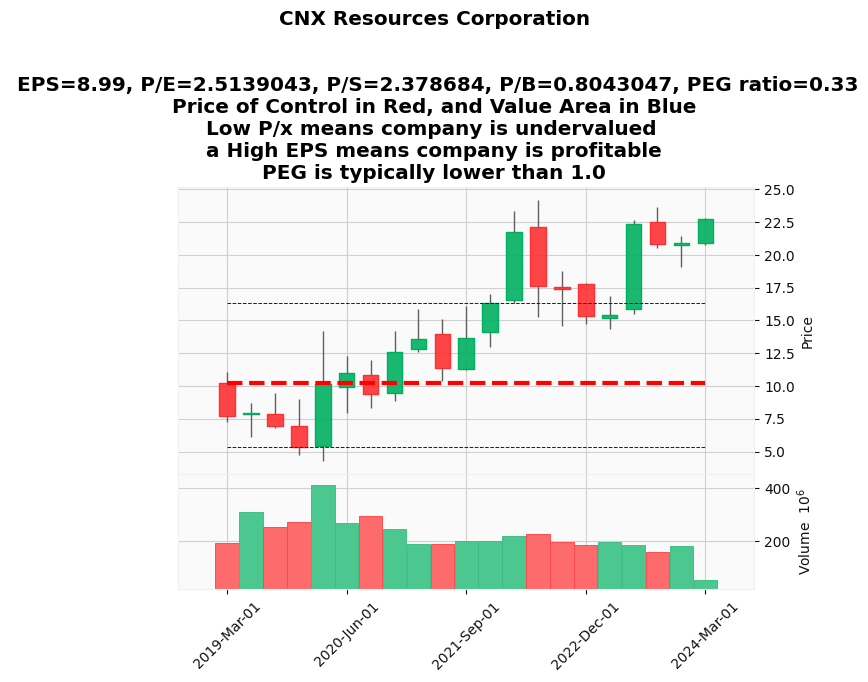

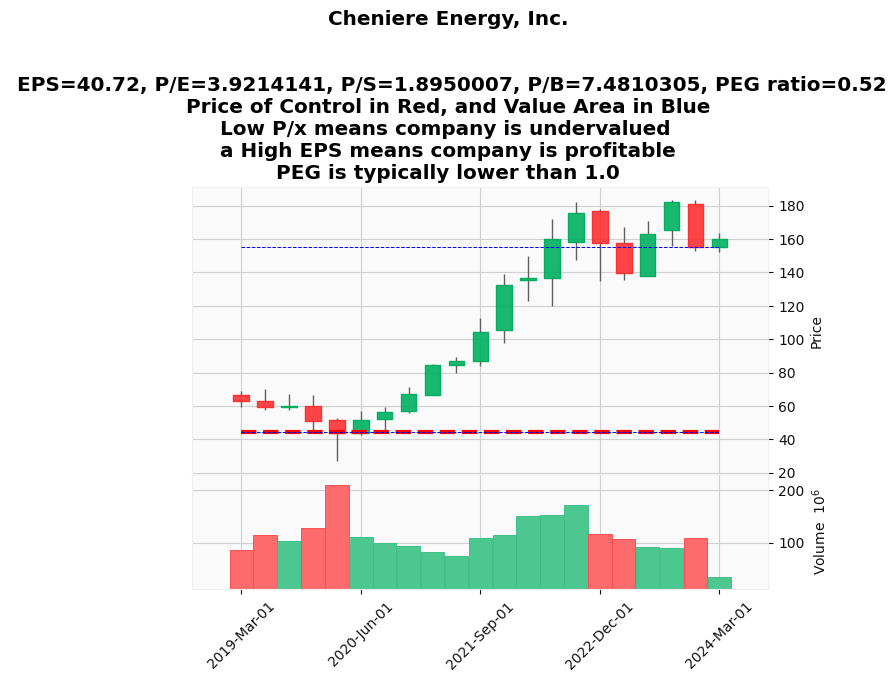

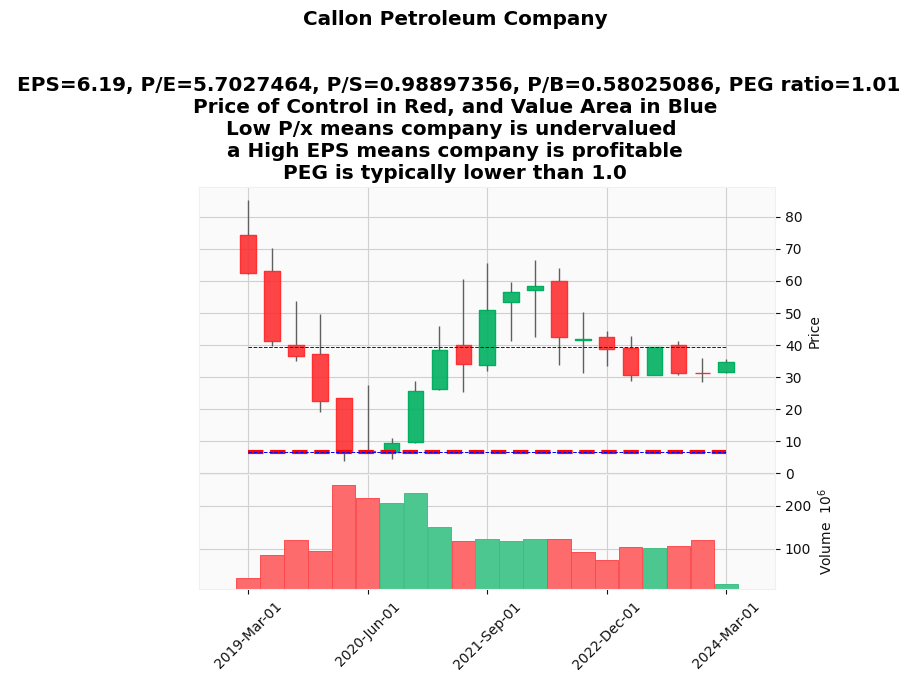

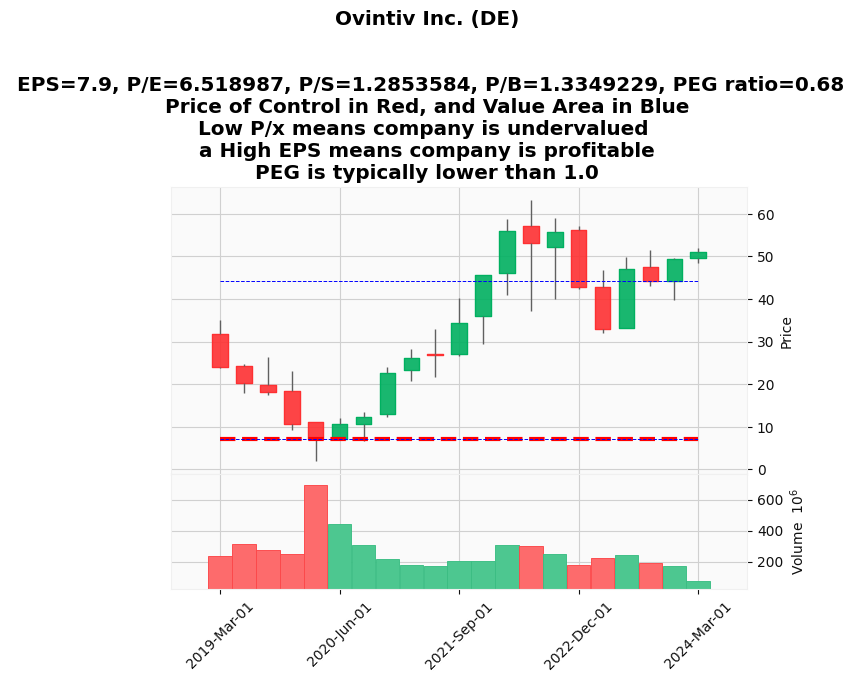

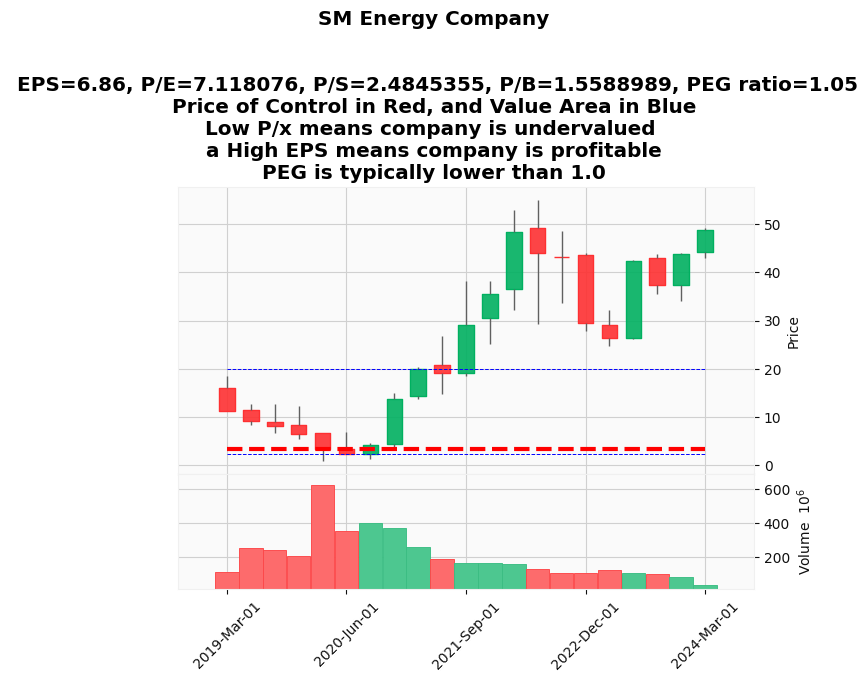

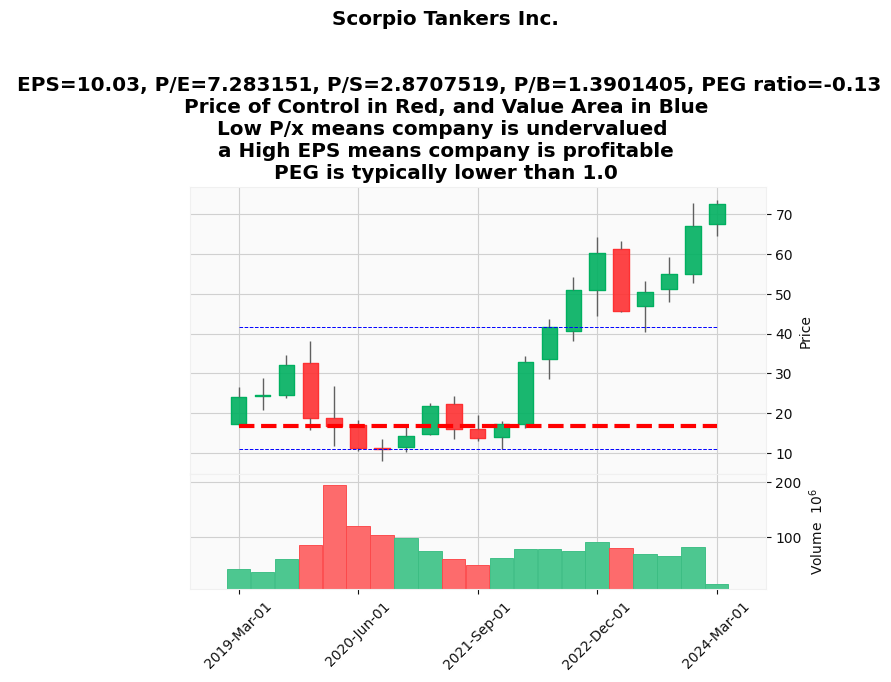

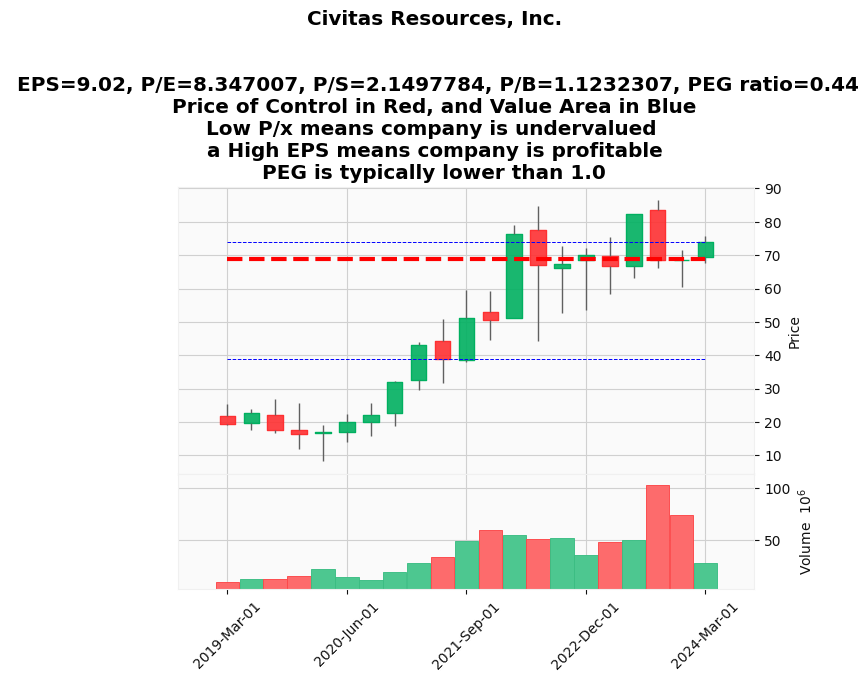

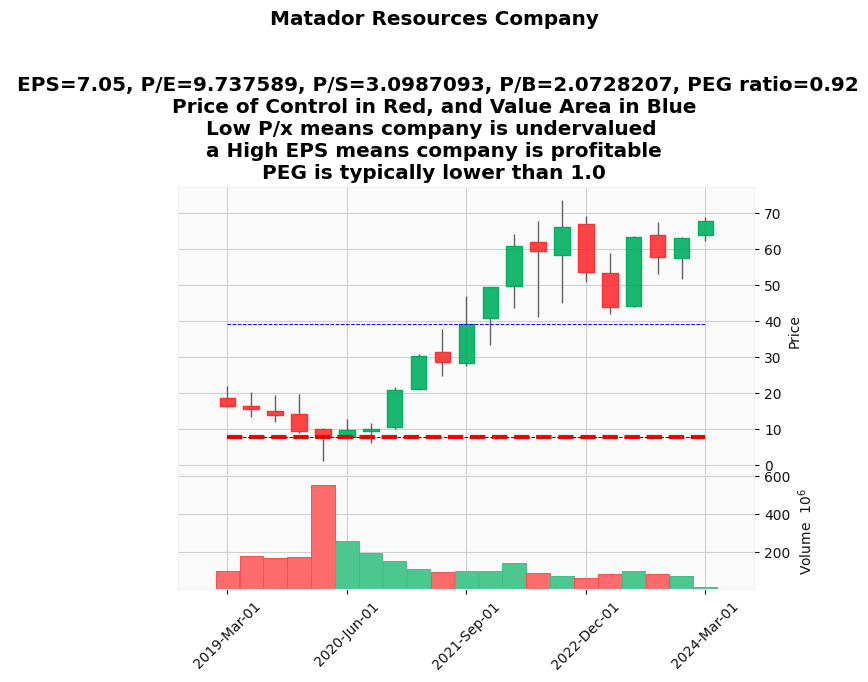

## Sector: Consumer Cyclical

<Figure size 640x480 with 0 Axes>

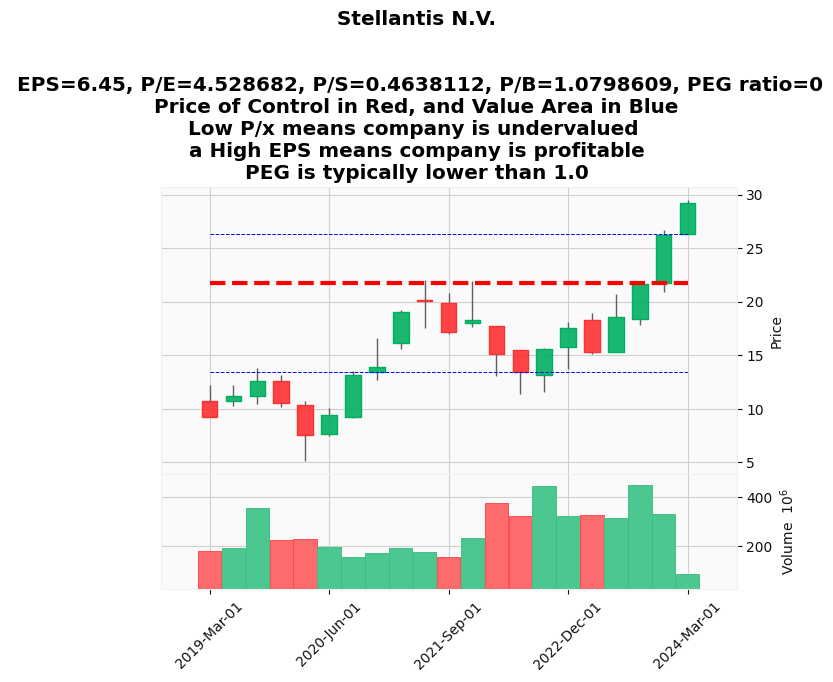

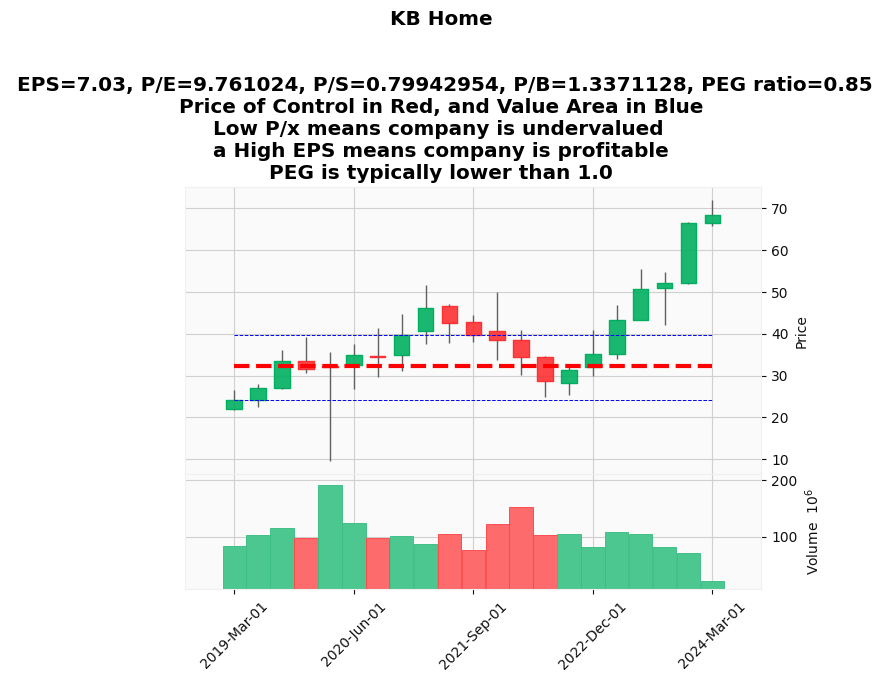

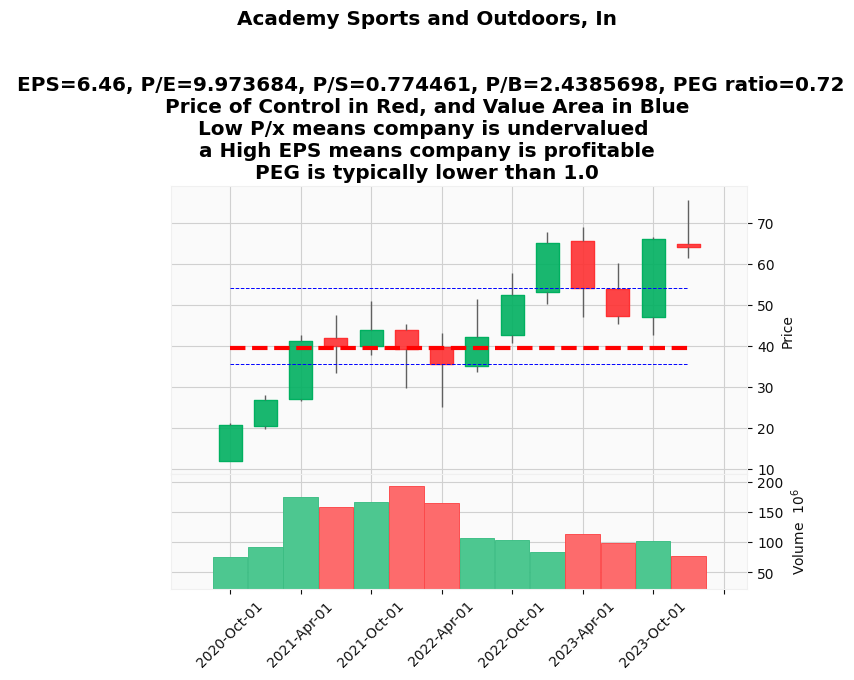

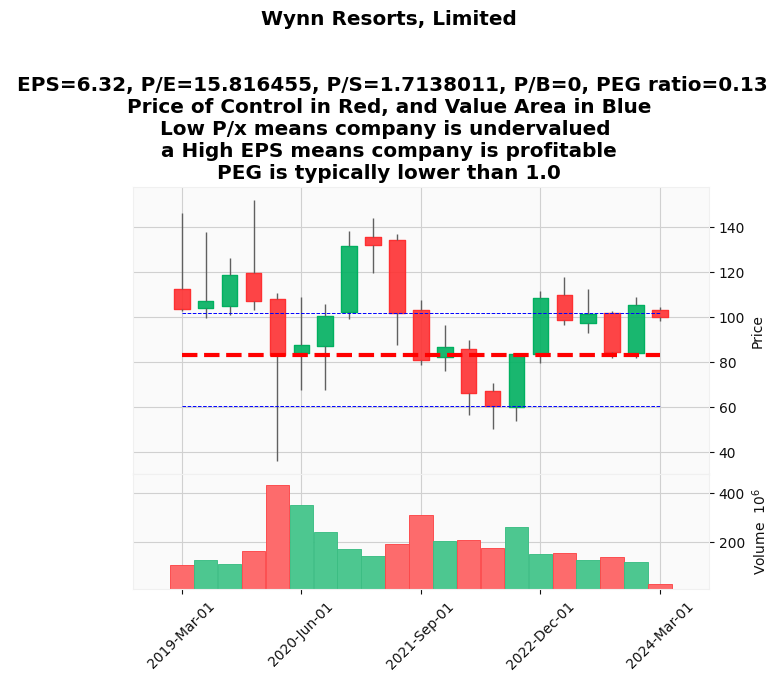

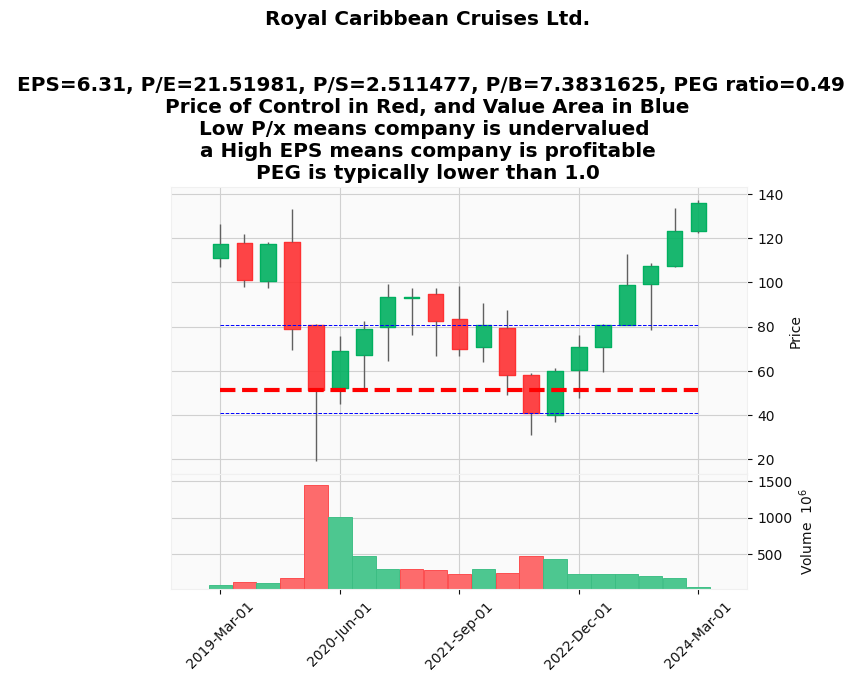

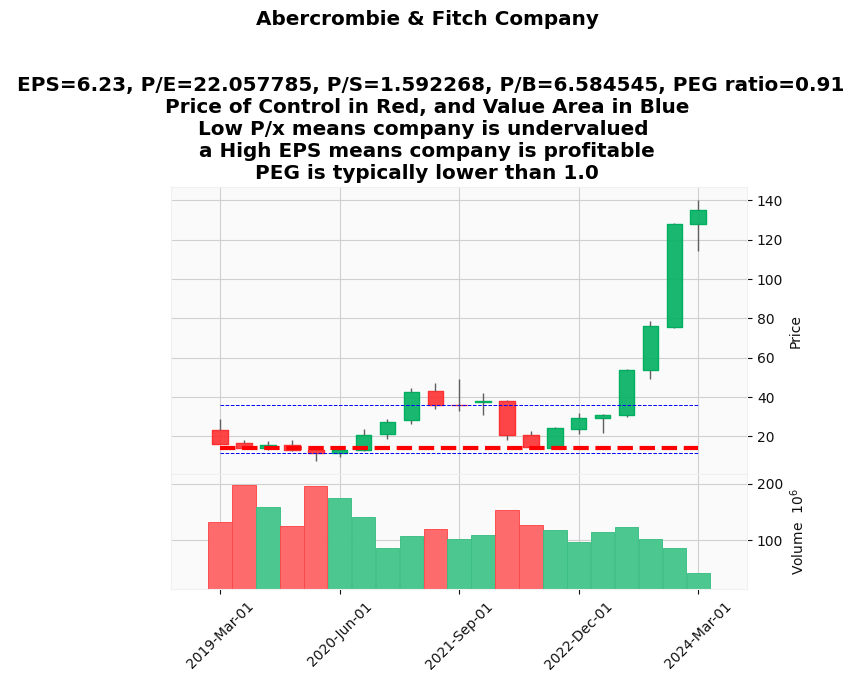

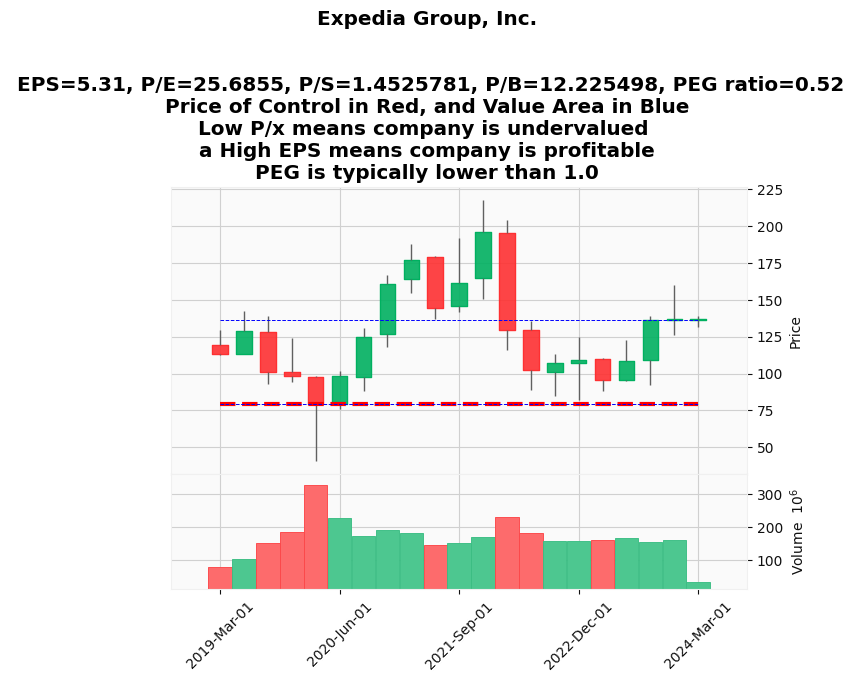

## Sector: Technology

<Figure size 640x480 with 0 Axes>

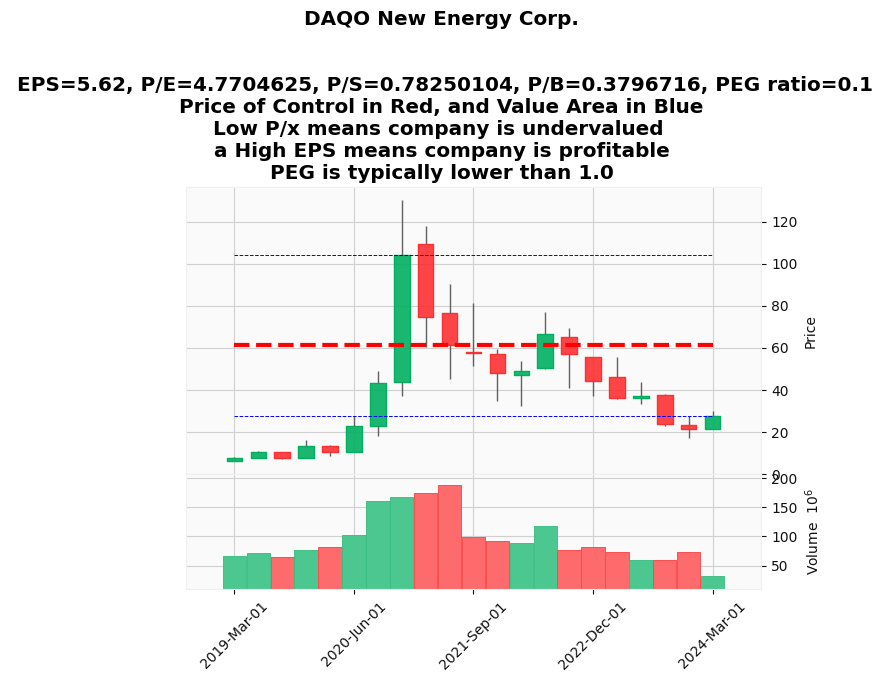

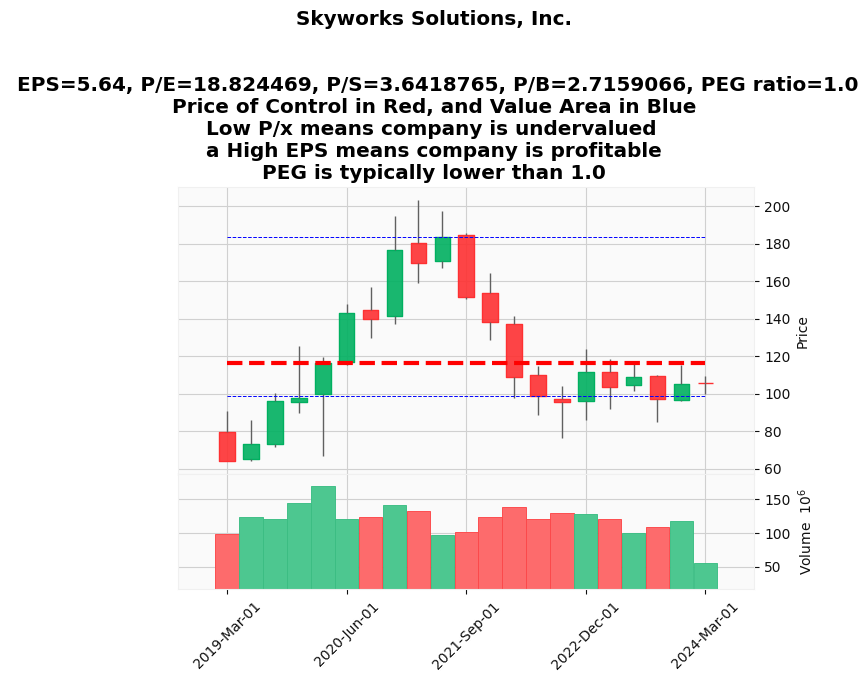

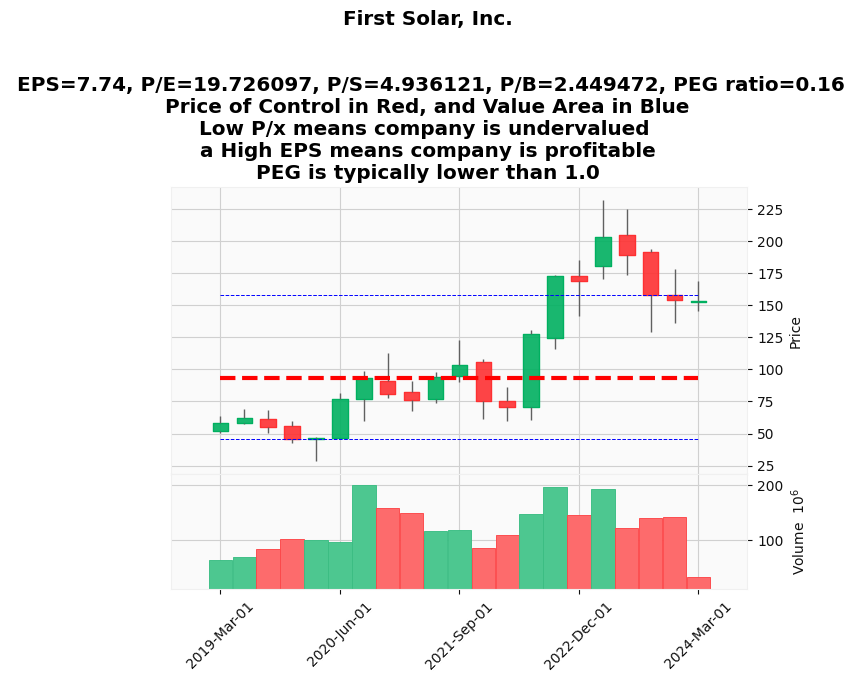

## Sector: Industrials

<Figure size 640x480 with 0 Axes>

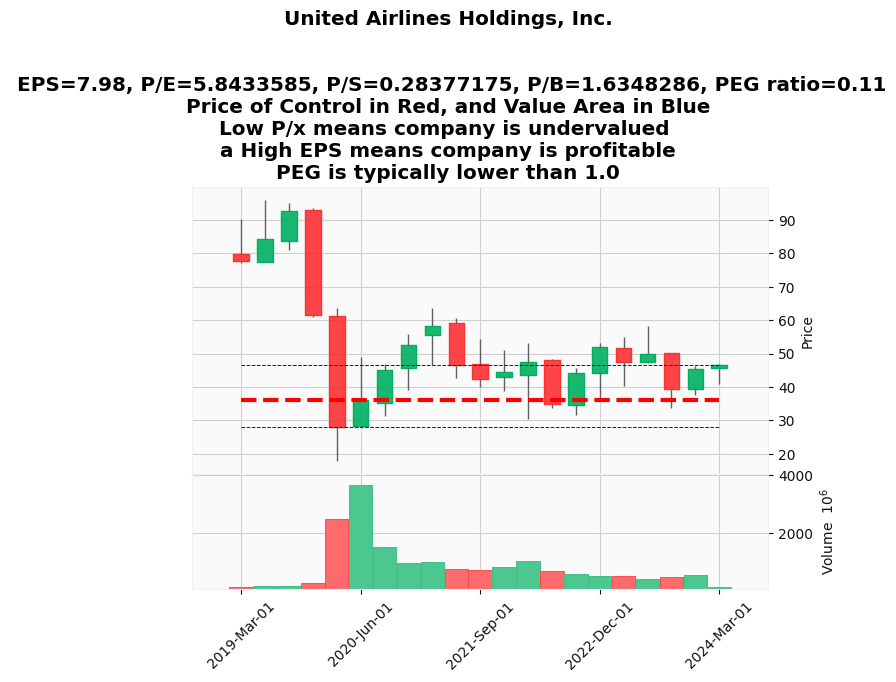

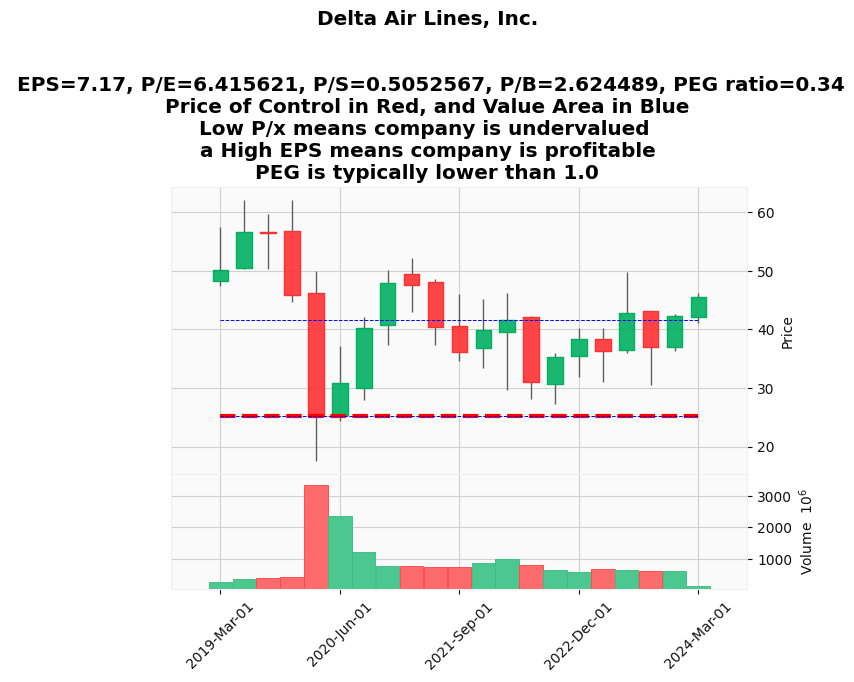

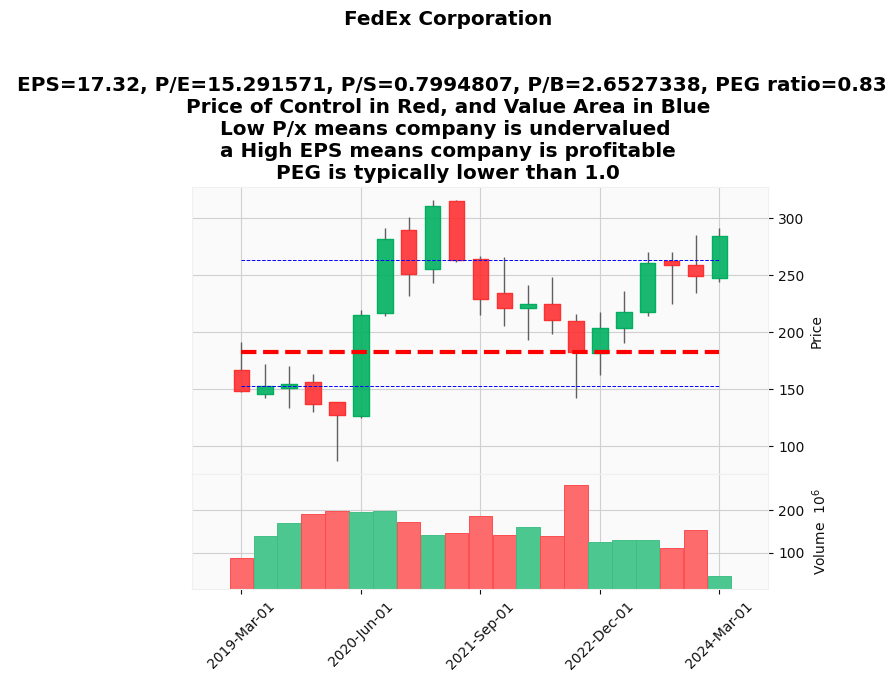

## Sector: Financial Services

<Figure size 640x480 with 0 Axes>

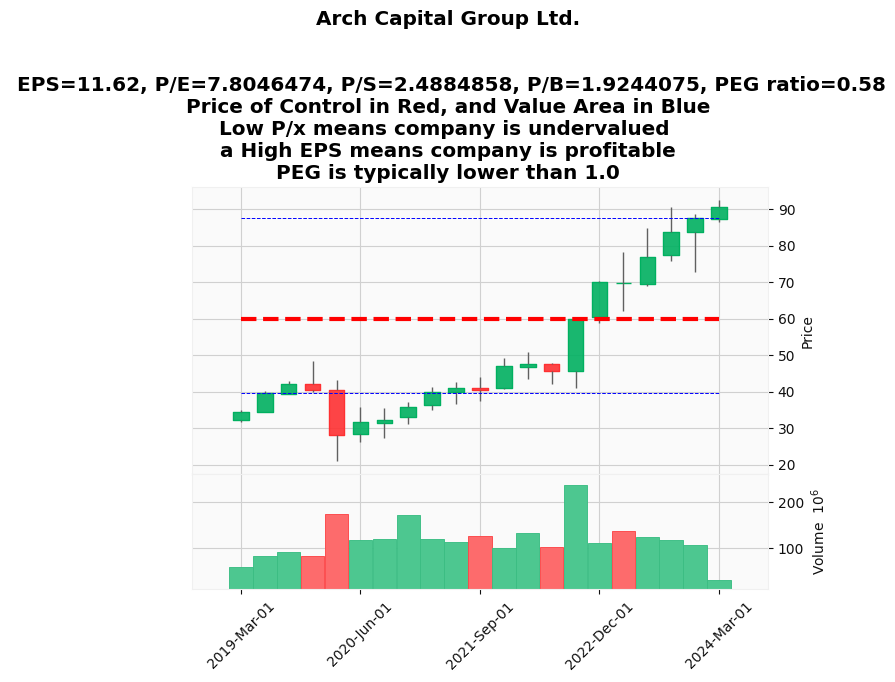

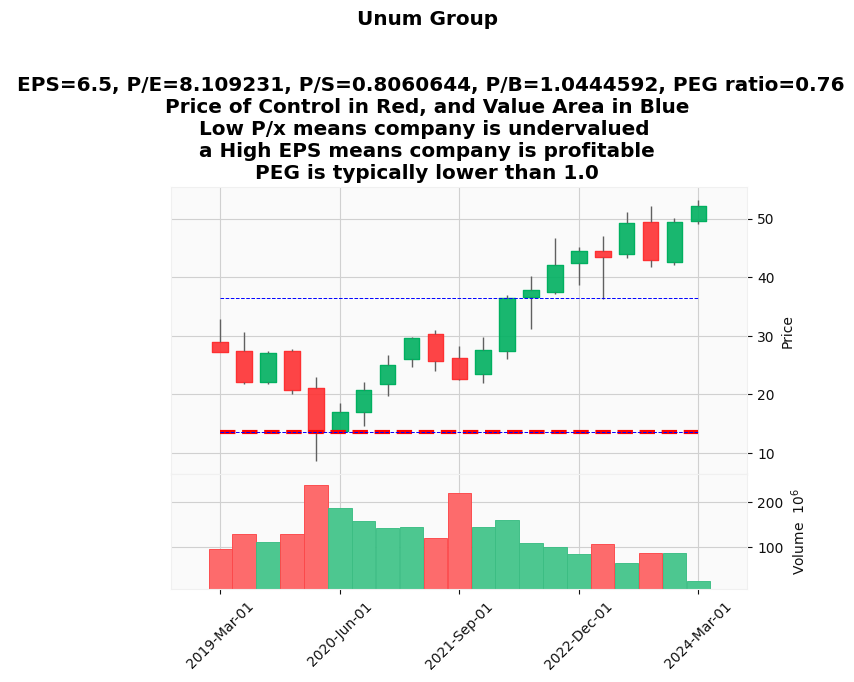

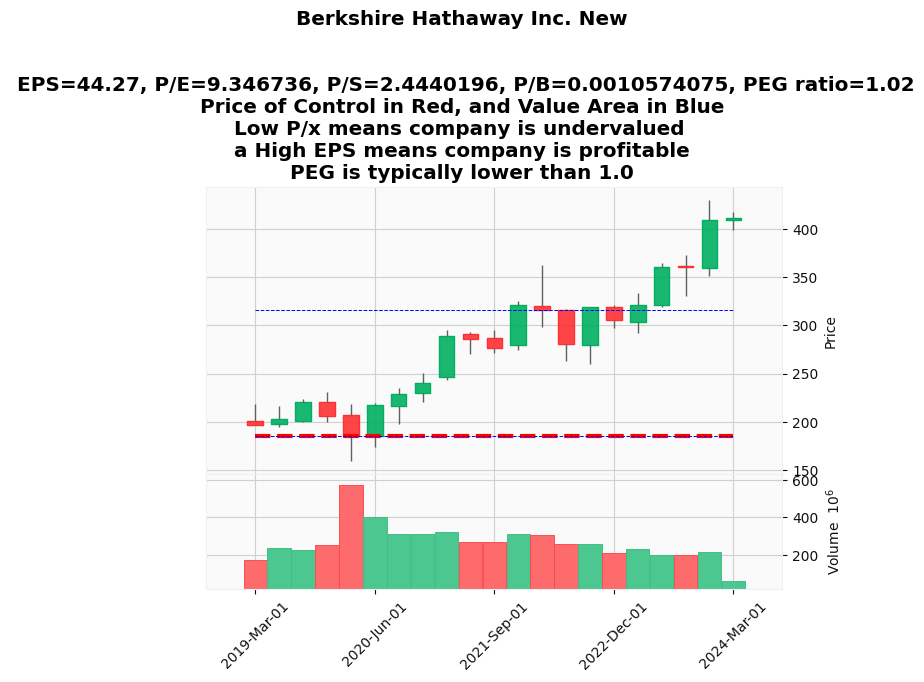

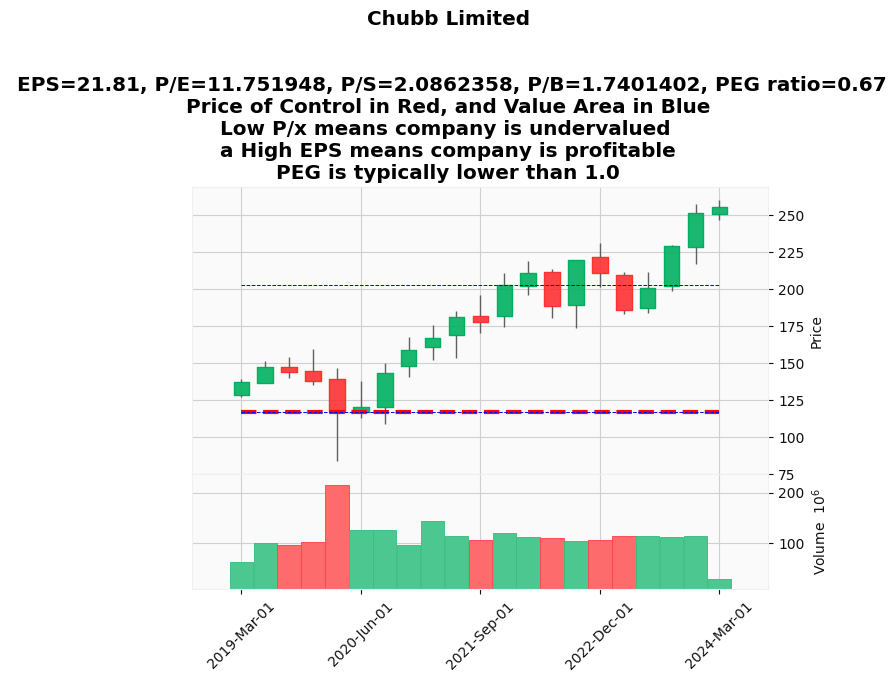

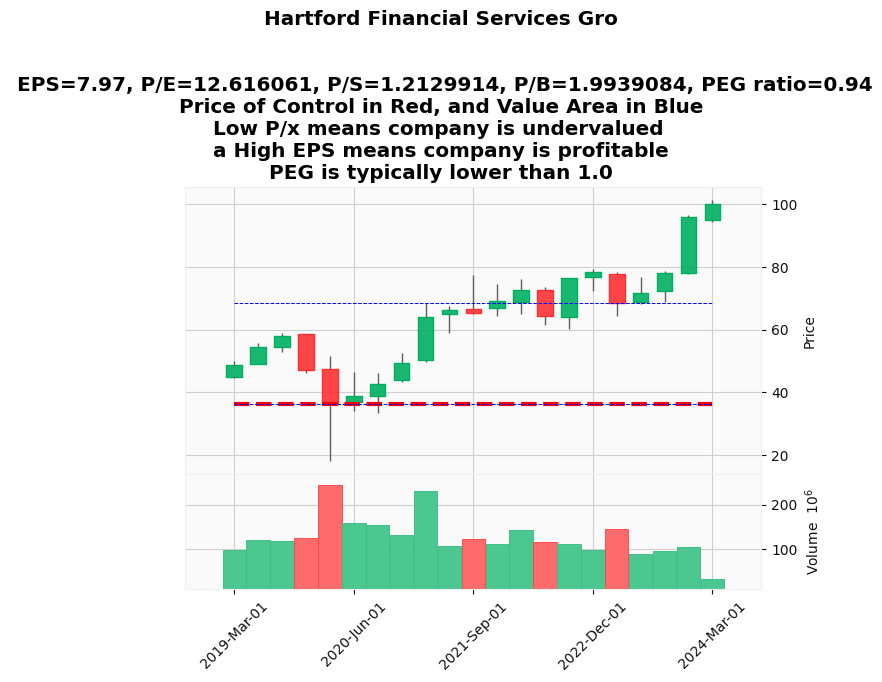

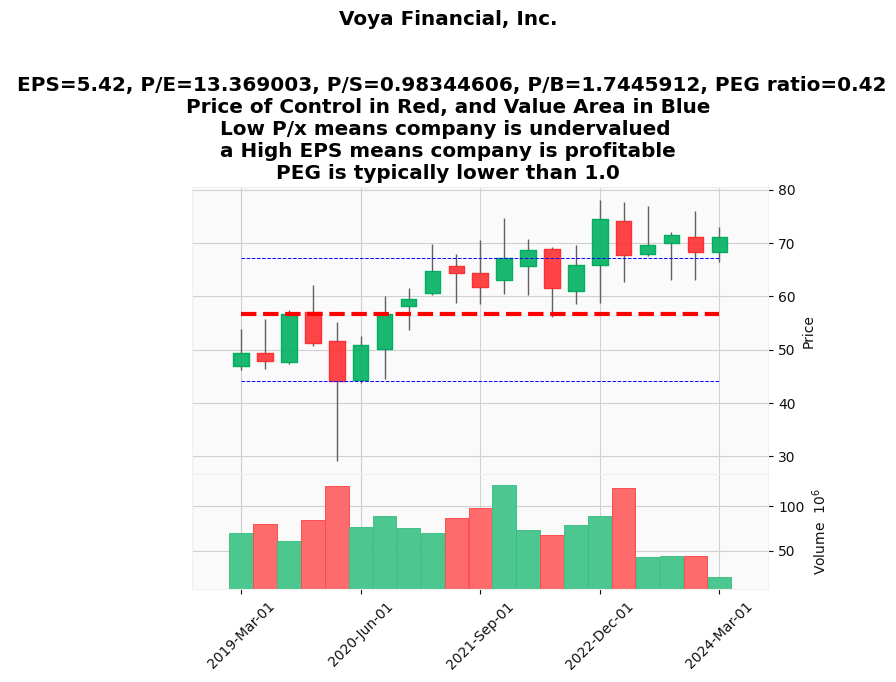

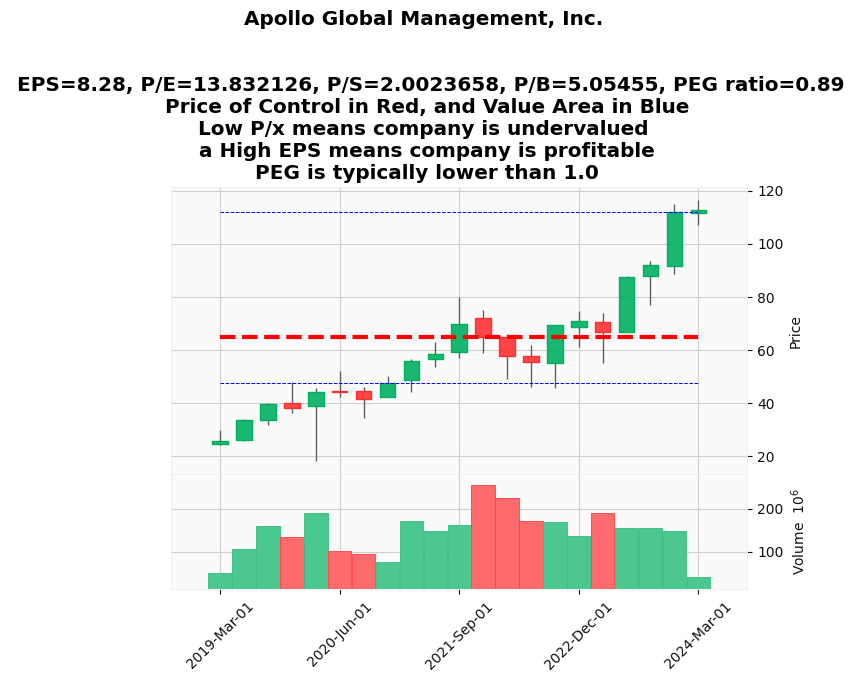

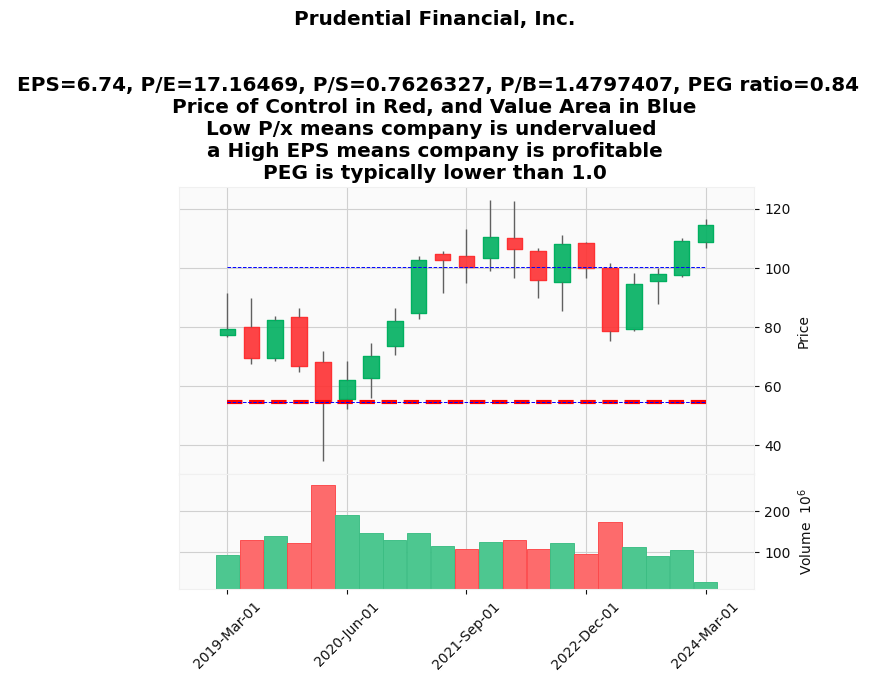

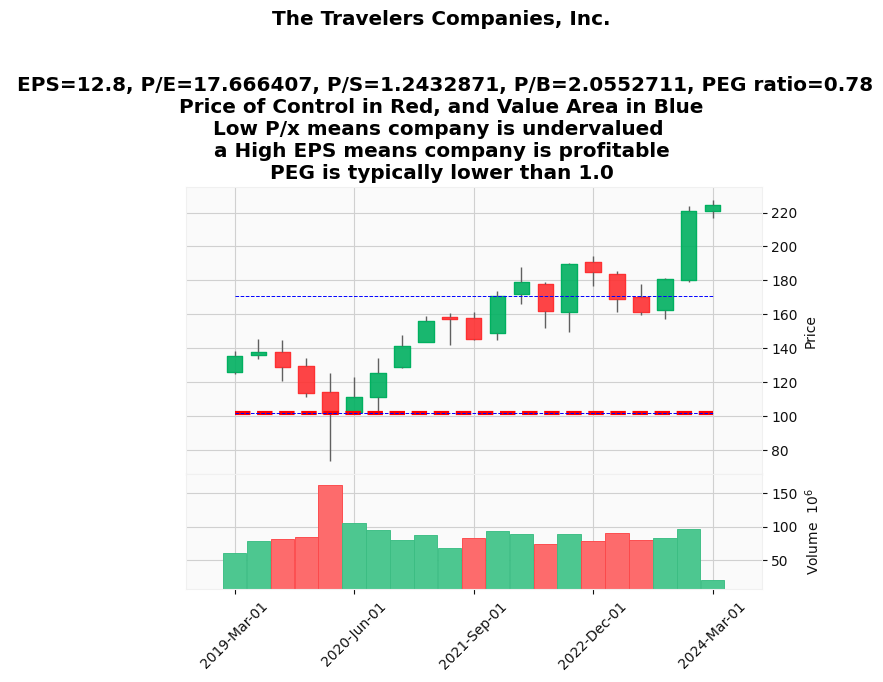

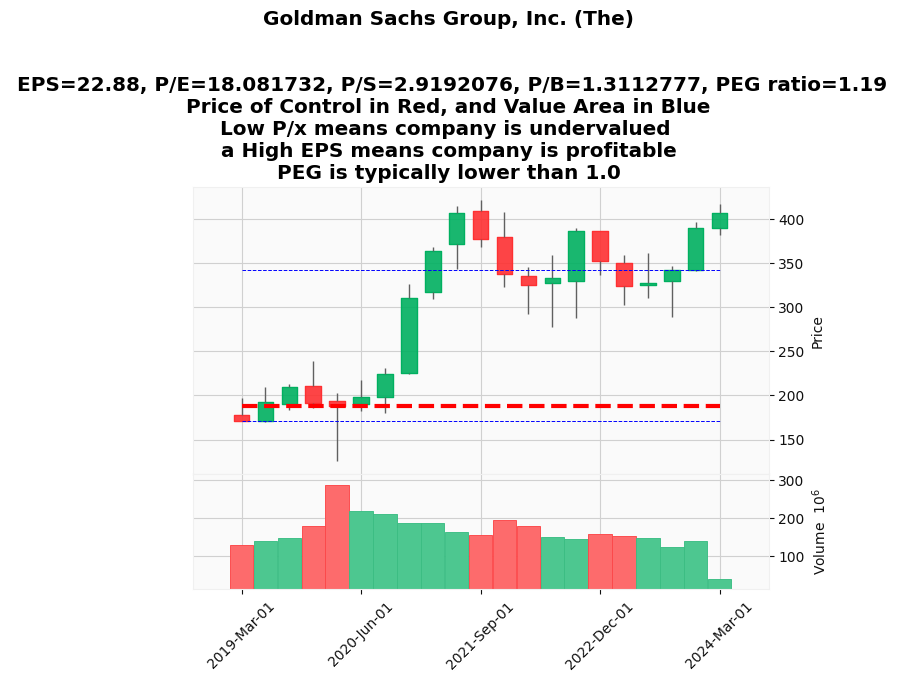

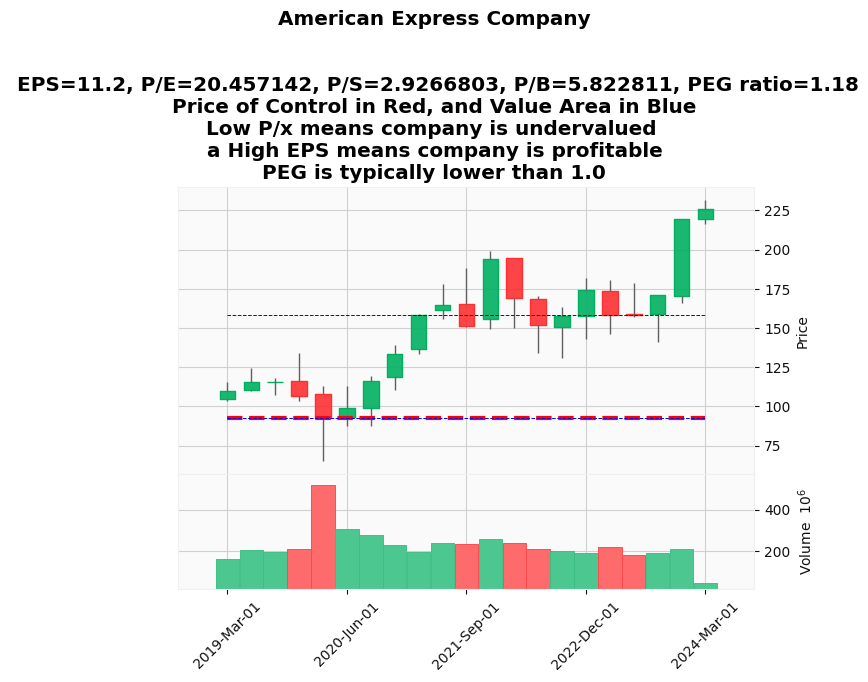

## Sector: Communication Services

<Figure size 640x480 with 0 Axes>

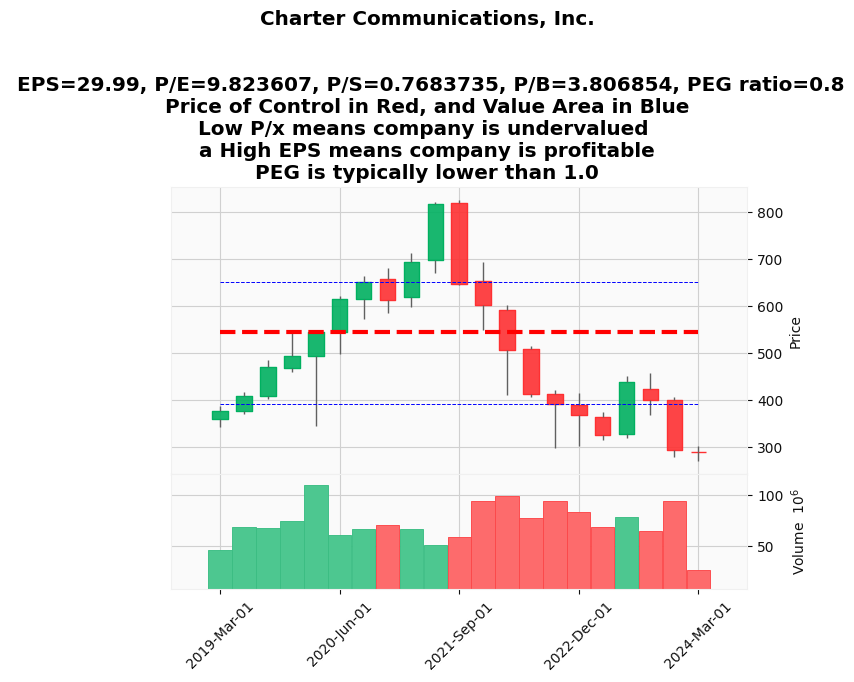

## Sector: Basic Materials

<Figure size 640x480 with 0 Axes>

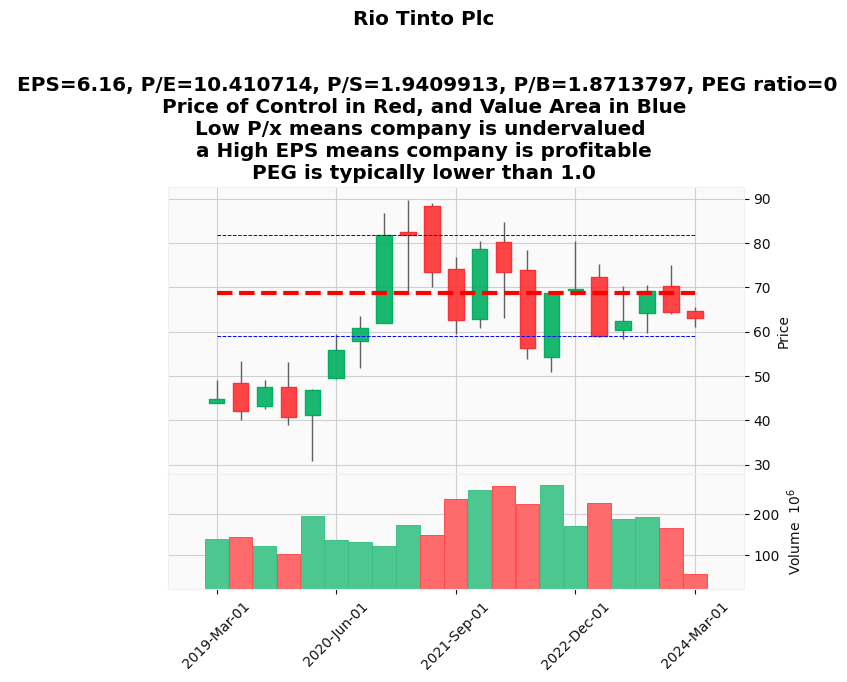

## Sector: Consumer Defensive

<Figure size 640x480 with 0 Axes>

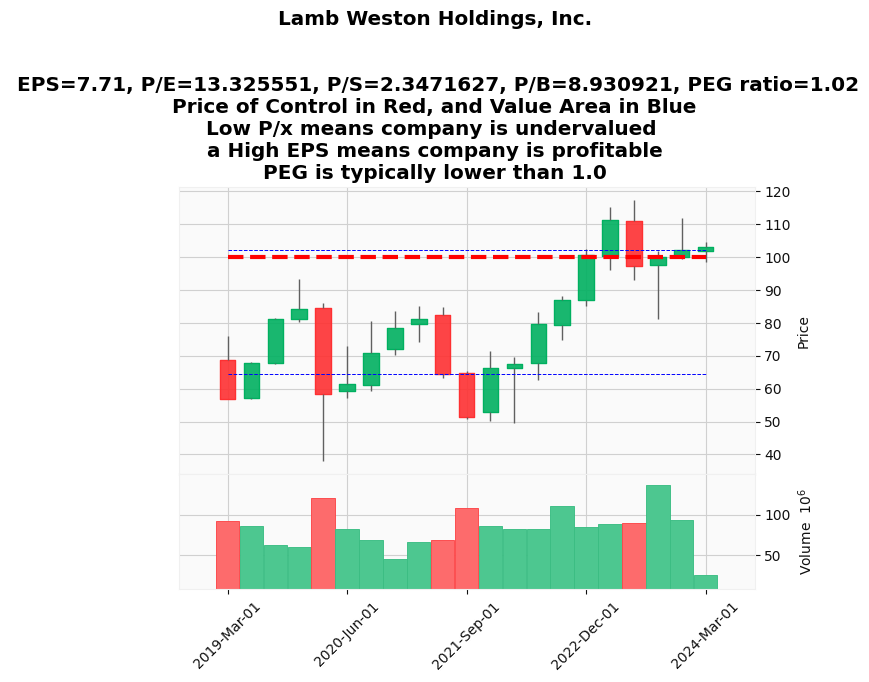

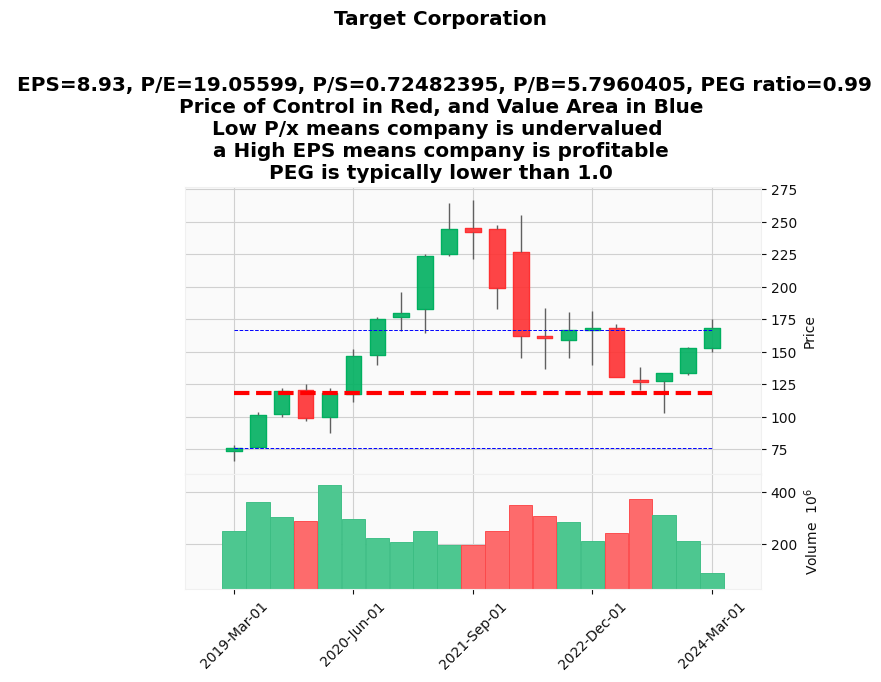

## Sector: Healthcare

<Figure size 640x480 with 0 Axes>

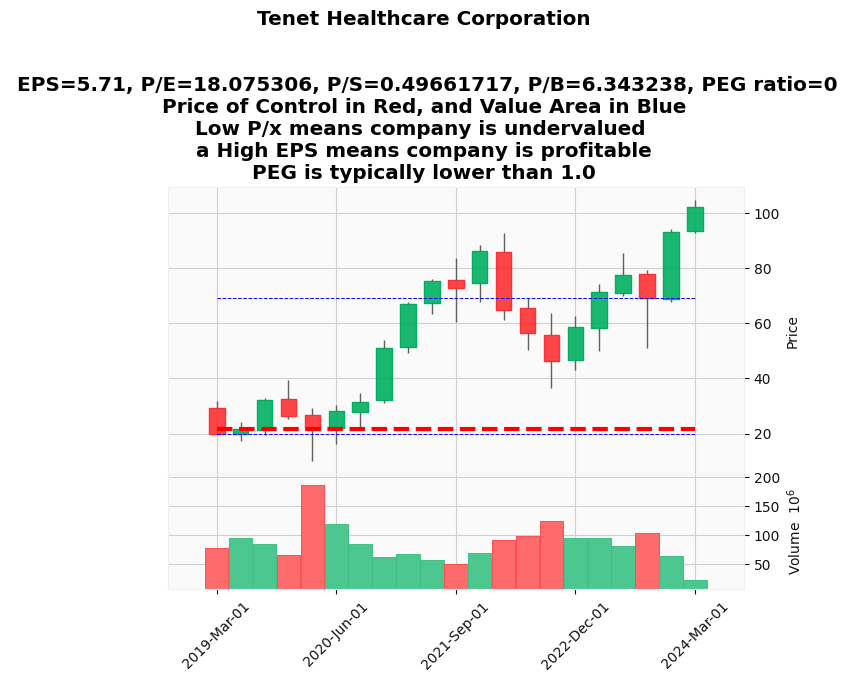

<Figure size 640x480 with 0 Axes>

In [142]:
def get_eps_pe_pb_ps_peg(ticker_symbol):
    try:
        if ticker_symbol in combined_metrics['company_labels']:
            index = combined_metrics['company_labels'].index(ticker_symbol)
            eps = combined_metrics['eps_values'][index]
            pe = combined_metrics['pe_values'][index]
            ps = combined_metrics['ps_values'][index]
            pb = combined_metrics['pb_values'][index]
            peg = combined_metrics['peg_values'][index]

            return eps, pe, ps, pb, peg
        else:
            # This line is crucial as it will inform us if the ticker was not found in our labels list.
            print(f"Ticker '{ticker_symbol}' not found in the labels list.")
            return None, None, None, None, None
    except Exception as e:
        # Catching any other potential error to understand what might have gone wrong.
        print(f"An error occurred: {e}")
        return None, None, None, None, None

def calculate_market_profile(data):
    mp = MarketProfile(data)
    mp_slice = mp[data.index.min():data.index.max()]

    # Access the attributes you're interested in
    va_high, va_low = mp_slice.value_area
    poc_price = mp_slice.poc_price  # Point of control price
    profile_range = mp_slice.profile_range

    return va_high, va_low, poc_price, profile_range

def plot_with_volume_profile(ticker_symbol, start_date, end_date):
    ticker = yf.Ticker(ticker_symbol)

    data = fetch_historical_data(ticker, start_date, end_date)
    eps, pe, ps, pb, peg = get_eps_pe_pb_ps_peg(ticker_symbol)  

    if not data.empty:
        va_high, va_low, poc_price, _ = calculate_market_profile(data)

        poc_line = pd.Series(poc_price, index=data.index)
        va_high_line = pd.Series(va_high, index=data.index)
        va_low_line = pd.Series(va_low, index=data.index)

        apds = [mpf.make_addplot(poc_line, type='line', color='red', linestyle='dashed', width=3),
                mpf.make_addplot(va_high_line, type='line', color='blue', linestyle='dashed', width=0.7),
                mpf.make_addplot(va_low_line, type='line', color='blue', linestyle='dashed', width=0.7)]

        title = f"{ticker.info['shortName']}\n\n\n EPS={eps}, P/E={pe}, P/S={ps}, P/B={pb}, PEG ratio={peg}\n"\
                "Price of Control in Red, and Value Area in Blue\n"\
                "Low P/x means company is undervalued \n"\
                "a High EPS means company is profitable\n"\
                "PEG is typically lower than 1.0\n\n\n"

        mpf.plot(data, type="candle", addplot=apds, title=title, style="yahoo", volume=True, show_nontrading=False)
    else:
        print(f"No data found for {ticker_symbol} in the given date range.")

def plot_candle_charts_per_sector(industries, start_date, end_date):
    for sector, symbol_list in industries.items():
        display(Markdown(f"## Sector: {sector}"))  

        for symbol in symbol_list:
            plot_with_volume_profile(symbol, start_date, end_date)  

        plt.tight_layout()

    plt.show()

plot_candle_charts_per_sector(filtered_industries, start_date_str, end_date_str)